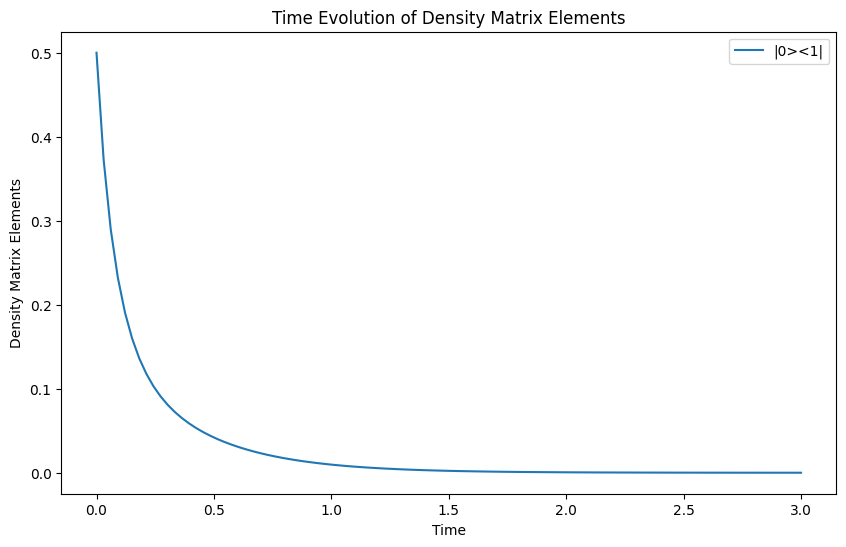

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp

def init_state(dim, n, m):
    """Initialize the ground state of the system."""
    state = np.zeros((dim, 1), dtype=complex)
    state[n] = 1.0  
    state[m] = 1.0
    return state * np.sqrt(1.0 / 2) 

gamma = 1.0

def a(dim):
    vec = np.sqrt(np.linspace(1, dim-1, dim-1))
    # creates a vector of the dim-1 off-diagonal elements
    A = np.diag(vec, +1)

    return A

def a_dag(dim):
    return a(dim).conjugate().T

def rho_vector_state(state):
    """Convert the density matrix to a vector state."""
    return np.kron(state, state.conjugate())

dim = 5
N_th = 5


def rhodot(t, rho, N_th, dim):
    evolved = gamma/2*(N_th+1)*(2 * np.kron(a(dim), a_dag(dim).T) @ rho - np.kron(a_dag(dim) @ a(dim), np.identity(dim)) @ rho - np.kron(np.identity(dim), (a_dag(dim) @ a(dim)).T) @ rho) 
    evolved += gamma/2*N_th*(2 * np.kron(a_dag(dim), a(dim).T) @ rho - np.kron(a(dim) @ a_dag(dim), np.identity(dim)) @ rho - np.kron(np.identity(dim), (a(dim) @ a_dag(dim)).T) @ rho)
    return evolved


t_span = np.linspace(0, 3, 100)
sol = solve_ivp(rhodot,(t_span[0],t_span[-1]),rho_vector_state(init_state(dim, 0, 1)).flatten(),t_eval=t_span, args=[N_th,dim])
rho_t = sol.y

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(t_span, rho_t[1], label='|0><1|')

plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.legend()
plt.show()




## Part 17a)

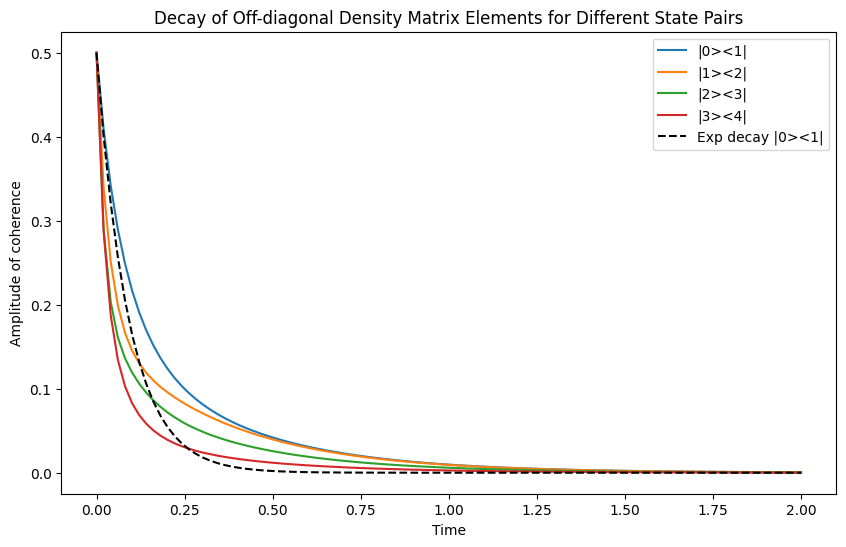

In [23]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

def init_state(dim, n, m):
    """Initialize a state as an equal superposition of |n> and |m>."""
    state = np.zeros((dim, 1), dtype=complex)
    state[n] = 1.0  
    state[m] = 1.0
    return state * (1/np.sqrt(2))

gamma = 1.0

def a(dim):
    # Create a vector of the sqrt of 1, 2, ... up to dim-1 and make the off-diagonal matrix.
    vec = np.sqrt(np.arange(1, dim))
    A = np.diag(vec, k=1)
    return A

def a_dag(dim):
    return a(dim).conjugate().T

def rho_vector_state(state):

    return np.kron(state, state.conjugate()).flatten()

dim = 5
N_th = 5

def rhodot(t, rho, N_th, dim):
    evolved = gamma/2*(N_th+1)*(2 * np.kron(a(dim), a_dag(dim).T) @ rho - np.kron(a_dag(dim) @ a(dim), np.identity(dim)) @ rho - np.kron(np.identity(dim), (a_dag(dim) @ a(dim)).T) @ rho) 
    evolved += gamma/2*N_th*(2 * np.kron(a_dag(dim), a(dim).T) @ rho - np.kron(a(dim) @ a_dag(dim), np.identity(dim)) @ rho - np.kron(np.identity(dim), (a(dim) @ a_dag(dim)).T) @ rho)
    return evolved

# Time span for the simulation
t_span = np.linspace(0, 2, 100)

# Define the pairs to test.
pairs = [(0, 1), (1, 2), (2, 3), (3, 4)]
solutions = {}  # will store the time evolution for each pair

# Loop over each pair and solve the evolution.
for n, m in pairs:
    # Build the initial state and convert the density matrix to a 1D vector.
    init_rho = rho_vector_state(init_state(dim, n, m))
    
    # Solve the IVP for the vectorized density matrix.
    sol = solve_ivp(rhodot, (t_span[0], t_span[-1]), init_rho,
                    t_eval=t_span, args=(N_th, dim))
    
    solutions[(n, m)] = sol.y

# Create the plot.
plt.figure(figsize=(10, 6))
for (n, m), rho_t in solutions.items():
    idx = n * dim + m
    plt.plot(t_span, np.abs(rho_t[idx]), label=f'|{n}><{m}|')


def exp_funktion(t,gamma, dim, N_th,n,m):
    """Exponential decay function for the coherence."""
    Gamma = gamma*(2*(N_th+1)*(n+m)+2*N_th)
    return 0.5*np.exp(-Gamma/2 * t)

plt.plot(t_span, exp_funktion(t_span, gamma, dim, N_th, 0, 1), 'k--', label='Exp decay |0><1|')
plt.xlabel('Time')
plt.ylabel('Amplitude of coherence')
plt.title('Decay of Off-diagonal Density Matrix Elements for Different State Pairs')
plt.legend()
plt.show()


For all pairs of n,m tested, the exponential approximation is always faster than the corresponding numeric simulation decay.

## Part 17b)

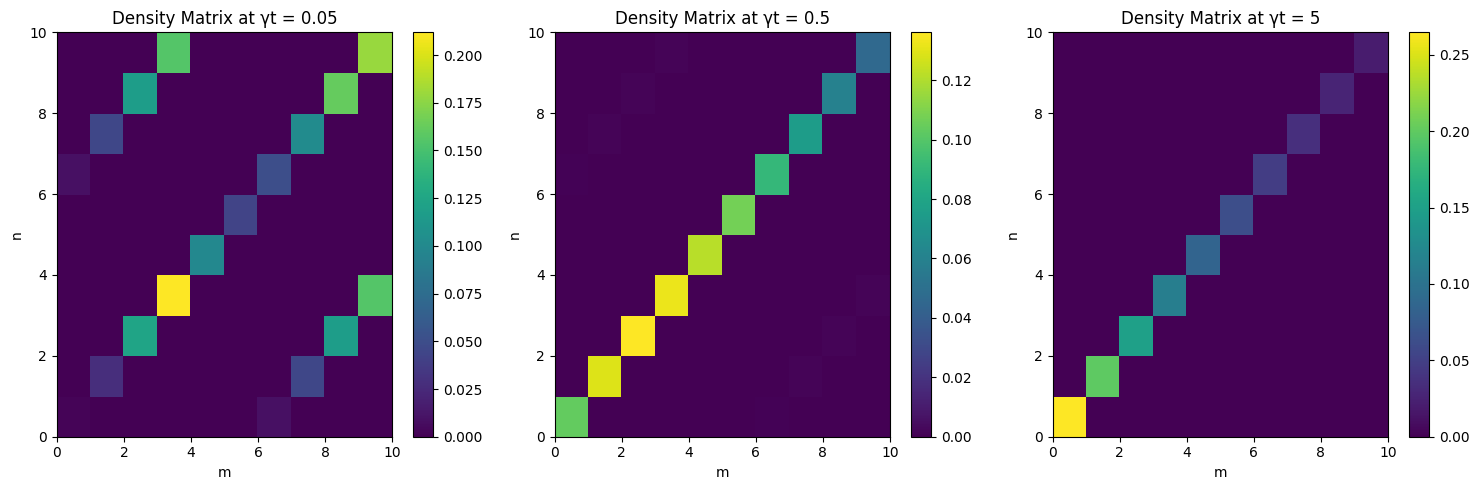

In [ ]:

dim = 10
N_th = 3
times = [0.05, 0.5, 5] 


density_matrices = {}
for t_final in times:
    sol = solve_ivp(rhodot, (0, t_final), rho_vector_state(init_state(dim, 3, 9)), args=[N_th, dim])
    rho_vector = sol.y[:, -1] 
    rho_matrix = rho_vector.reshape(dim, dim)  
    density_matrices[t_final] = rho_matrix

fig, axes = plt.subplots(1, len(times), figsize=(15, 5))
for i, t_final in enumerate(times):
    ax = axes[i]
    rho_matrix = density_matrices[t_final].real  
    c = ax.pcolor(rho_matrix, cmap='viridis', shading='auto')
    ax.set_title(f"Density Matrix at γt = {t_final}")
    ax.set_xlabel("m")
    ax.set_ylabel("n")
    fig.colorbar(c, ax=ax)

plt.tight_layout()
plt.show()

Vary the choice of n,m: the steady state is still the thermal state!